## Image-to-Mesh Model Evaluation

This notebook aims to evaluate the performance of the reimplemented ONET model by comparing its output metrics against reported results from the original paper. The evaluation focuses on understanding the model's strengths and weaknesses across different object classes.

### Notebook Content:
*   **Data Loading and Initial Inspection**: Loading the evaluation data from a `.pkl` file and displaying basic information about the dataset.
*   **Data Preprocessing**: Handling missing values and dropping irrelevant columns.
*   **Exploratory Data Analysis (EDA)**: Visualizing the distribution of key metrics like IOU, Normals, and Chamfer-L1 for various object classes using box plots.
*   **Performance Comparison**: Comparing the model's average performance metrics with the paper's reported results for each class.
*   **Result Explanation**: Detailed analysis of the model's performance, identifying best and worst-performing classes, and interpreting the differences observed compared to the paper.

In [2]:
# Data Loading and Initial Inspection

import pickle
import pandas as pd

file_path = "/content/drive/MyDrive/occupancy_networks_3d_reconstruction/eval_meshes_full.pkl"

# Load the .pkl file
with open(file_path, 'rb') as f:
    data = pickle.load(f)

print("Shape:", data.shape)
print("\nColumns:", data.columns.tolist())
display(data.head())



Shape: (8751, 14)

Columns: ['class id', 'class name', 'modelname', 'completeness (mesh)', 'accuracy (mesh)', 'normals completeness (mesh)', 'normals accuracy (mesh)', 'normals (mesh)', 'completeness2 (mesh)', 'accuracy2 (mesh)', 'chamfer-L2 (mesh)', 'chamfer-L1 (mesh)', 'iou (mesh)', 'chamfer (mesh)']


/tmp/ipykernel_7294/3291285535.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


,class id,class name,modelname,completeness (mesh),accuracy (mesh),normals completeness (mesh),normals accuracy (mesh),normals (mesh),completeness2 (mesh),accuracy2 (mesh),chamfer-L2 (mesh),chamfer-L1 (mesh),iou (mesh),chamfer (mesh)
idx,,,,,,,,,,,,,,
0,02828884,bench,c83b3192c338527a2056b4bd5d870b47,0.022633,0.018320,0.788704,0.849908,0.819306,0.001543,0.000494,0.001019,0.020476,0.379414,NaN
1,02828884,bench,c8802eaffc7e595b2dc11eeca04f912e,0.023921,0.025243,0.704699,0.812084,0.758392,0.000894,0.001110,0.001002,0.024582,0.611690,NaN
2,02828884,bench,c89d4c95f1e7c950a805114916841d69,0.016126,0.016310,0.901348,0.906155,0.903752,0.000368,0.000389,0.000379,0.016218,0.612926,NaN
3,02828884,bench,c8a2ce0e65da4b817b11ae648ea92233,0.018256,0.016983,0.833036,0.857790,0.845413,0.000650,0.000558,0.000604,0.017620,0.537708,NaN
4,02828884,bench,c8fa692760ba875848d791284650e46d,0.016747,0.023087,0.668811,0.746774,0.707792,0.000435,0.001028,0.000732,0.019917,0.317122,NaN


In [3]:
print("Null values in each column:")
display(data.isnull().sum())

Null values in each column:


,0
class id,0
class name,0
modelname,0
completeness (mesh),16
accuracy (mesh),16
normals completeness (mesh),16
normals accuracy (mesh),16
normals (mesh),16
completeness2 (mesh),16
accuracy2 (mesh),16


In [4]:
# Data Preprocessing
# chamfer distance was not calculated in the original code

if 'chamfer (mesh)' in data.columns:
    data.drop('chamfer (mesh)', axis=1, inplace=True)
    print("Column 'chamfer (mesh)' dropped successfully.")
else:
    print("Column 'chamfer (mesh)' not found in the DataFrame.")

# Display the first few rows to confirm the change
display(data.head())

Column 'chamfer (mesh)' dropped successfully.


,class id,class name,modelname,completeness (mesh),accuracy (mesh),normals completeness (mesh),normals accuracy (mesh),normals (mesh),completeness2 (mesh),accuracy2 (mesh),chamfer-L2 (mesh),chamfer-L1 (mesh),iou (mesh)
idx,,,,,,,,,,,,,
0,02828884,bench,c83b3192c338527a2056b4bd5d870b47,0.022633,0.018320,0.788704,0.849908,0.819306,0.001543,0.000494,0.001019,0.020476,0.379414
1,02828884,bench,c8802eaffc7e595b2dc11eeca04f912e,0.023921,0.025243,0.704699,0.812084,0.758392,0.000894,0.001110,0.001002,0.024582,0.611690
2,02828884,bench,c89d4c95f1e7c950a805114916841d69,0.016126,0.016310,0.901348,0.906155,0.903752,0.000368,0.000389,0.000379,0.016218,0.612926
3,02828884,bench,c8a2ce0e65da4b817b11ae648ea92233,0.018256,0.016983,0.833036,0.857790,0.845413,0.000650,0.000558,0.000604,0.017620,0.537708
4,02828884,bench,c8fa692760ba875848d791284650e46d,0.016747,0.023087,0.668811,0.746774,0.707792,0.000435,0.001028,0.000732,0.019917,0.317122


In [5]:
# Exploratory Data Analysis (EDA)

display(data.describe())

,completeness (mesh),accuracy (mesh),normals completeness (mesh),normals accuracy (mesh),normals (mesh),completeness2 (mesh),accuracy2 (mesh),chamfer-L2 (mesh),chamfer-L1 (mesh),iou (mesh)
count,8735.000000,8735.000000,8735.000000,8735.000000,8735.000000,8735.000000,8735.000000,8713.000000,8713.000000,8735.000000
mean,0.037944,0.029418,0.784200,0.830693,0.807446,0.011963,0.009171,0.003019,0.029392,0.497801
std,0.092131,0.087379,0.134913,0.133668,0.131084,0.151764,0.150350,0.011577,0.023074,0.206068
min,0.005379,0.005495,-1.000000,-1.000000,-1.000000,0.000040,0.000038,0.000040,0.005462,0.000000
25%,0.018046,0.014870,0.730212,0.783844,0.759024,0.000587,0.000343,0.000534,0.017261,0.348714
50%,0.026250,0.020715,0.801164,0.853852,0.826980,0.001279,0.000693,0.001113,0.024113,0.487649
75%,0.038469,0.029437,0.859737,0.906921,0.879066,0.002864,0.001489,0.002343,0.034274,0.657408
max,1.732051,1.732051,0.986029,0.986878,0.986453,3.000000,3.000000,0.370465,0.424578,0.965548


## Core metrics distribution

**IOU (Intersection Over Union)**: This metric measures the overlap between the reconstructed 3D model and the ground truth. A higher IOU indicates a better fit and more accurate reconstruction. It ranges from 0 to 1, with 1 being a perfect overlap.

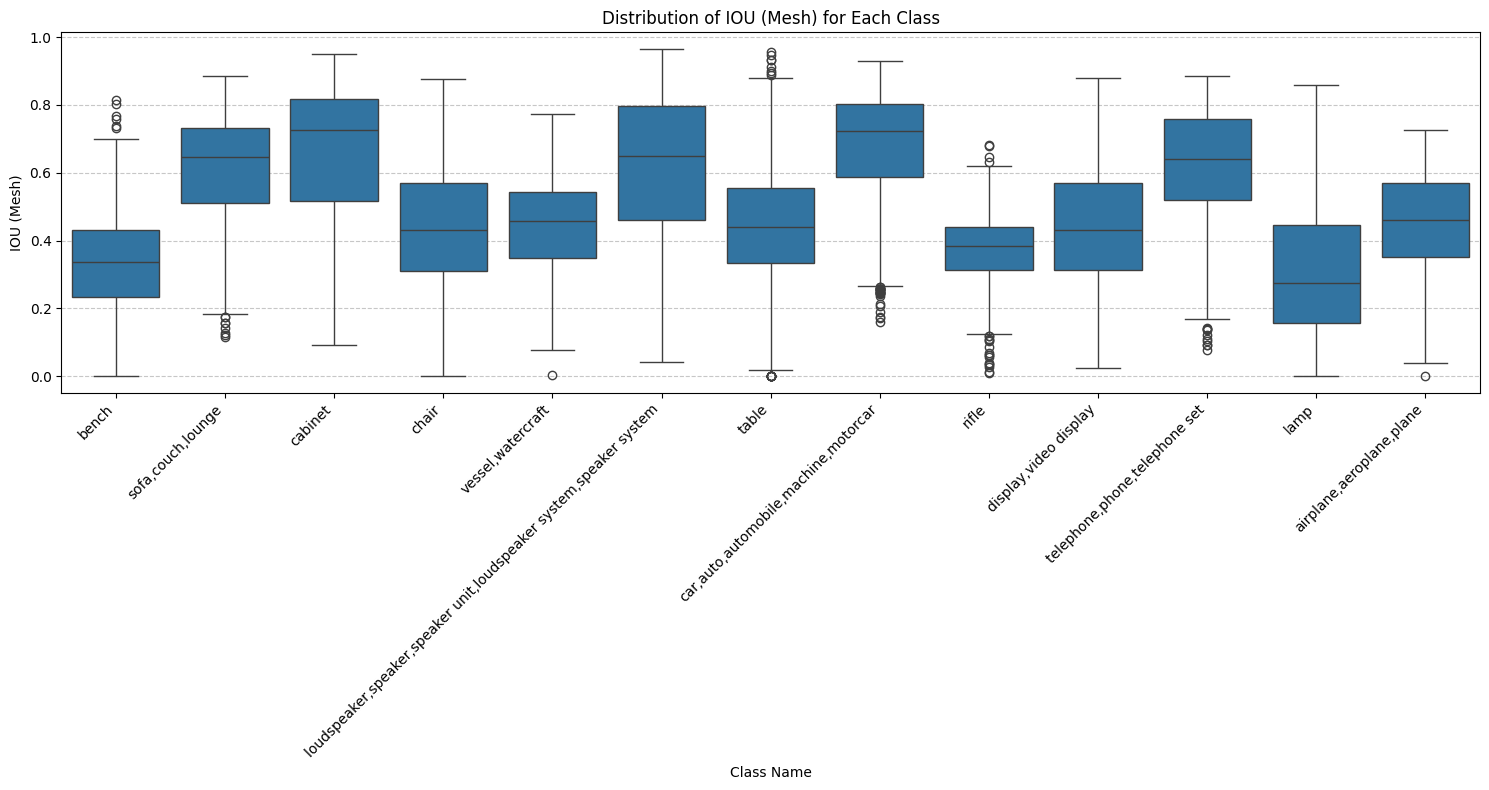

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='class name', y='iou (mesh)', data=data)
plt.title('Distribution of IOU (Mesh) for Each Class')
plt.xlabel('Class Name')
plt.ylabel('IOU (Mesh)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Normals (Mesh)**: This metric typically assesses the alignment of surface normals between the reconstructed mesh and the ground truth. A higher value suggests that the surface orientation of the reconstructed model closely matches the original object, which is crucial for visual quality and downstream tasks.

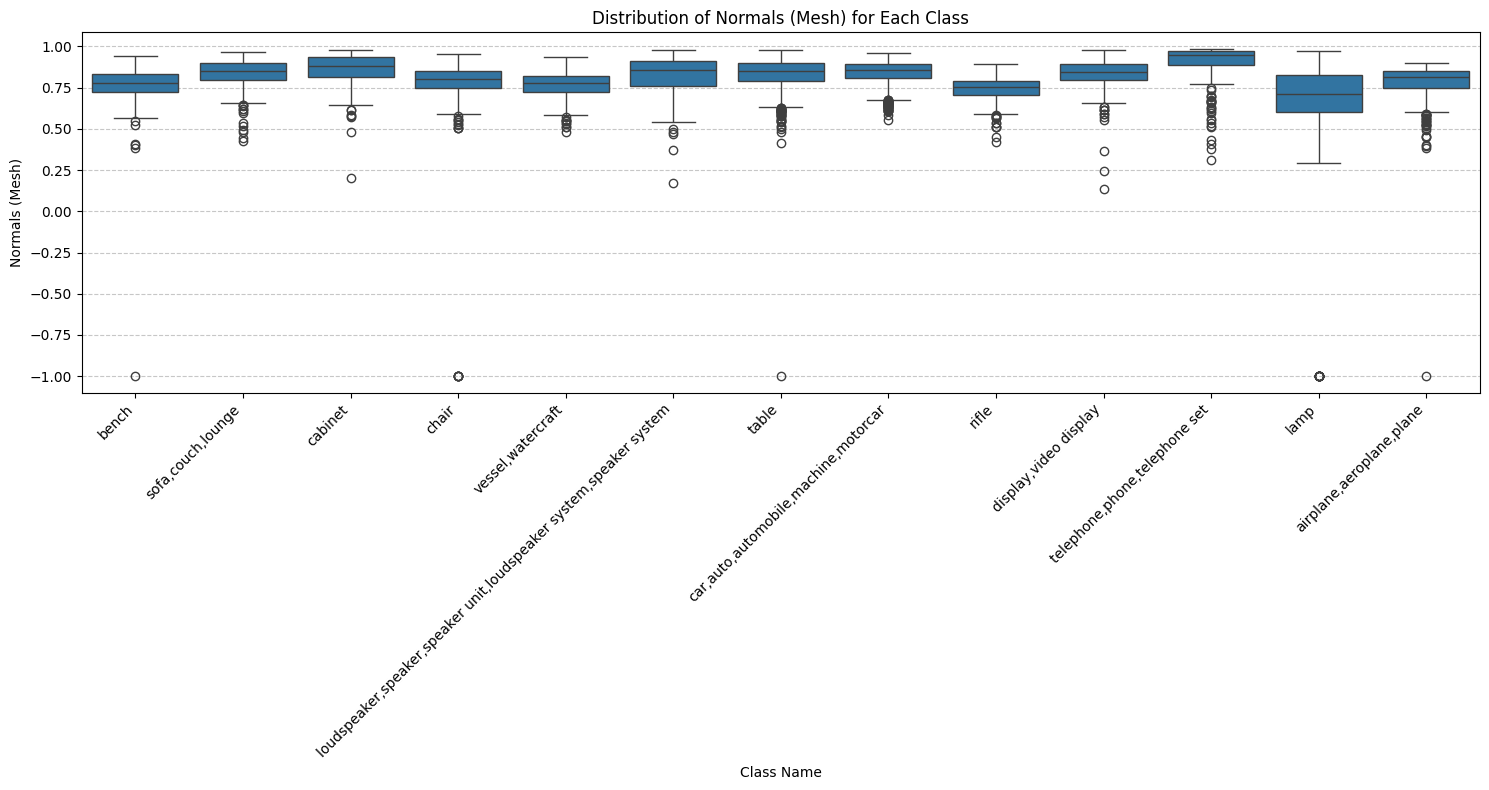

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='class name', y='normals (mesh)', data=data)
plt.title('Distribution of Normals (Mesh) for Each Class')
plt.xlabel('Class Name')
plt.ylabel('Normals (Mesh)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Chamfer-L1 (Chamfer Distance L1)**: Chamfer distance measures the average closest point distance between two point clouds (in this case, the reconstructed mesh and the ground truth). Chamfer-L1 is a variant that uses the L1 norm. A lower Chamfer-L1 value indicates that the reconstructed mesh is closer to the ground truth, implying higher accuracy.

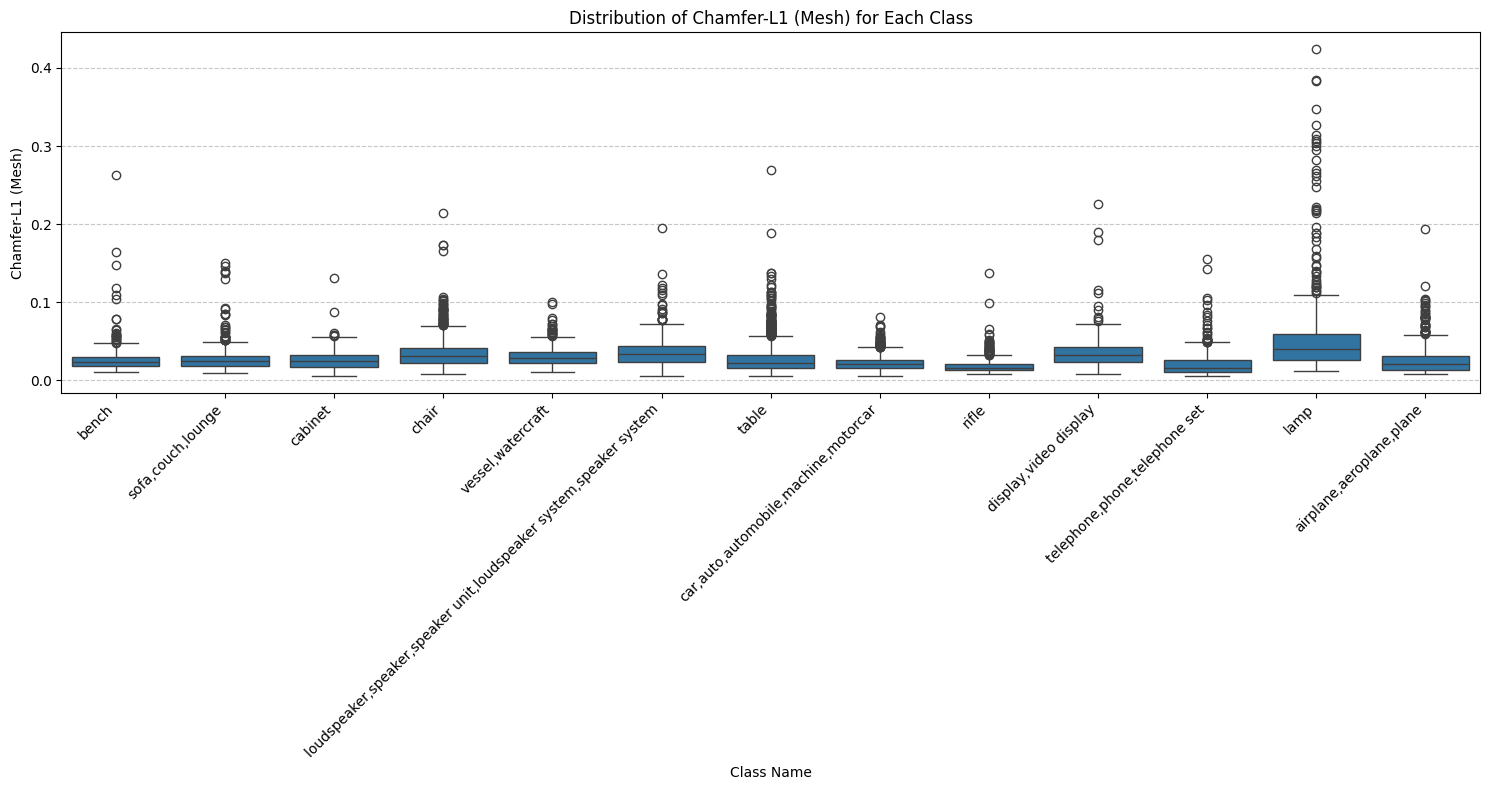

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='class name', y='chamfer-L1 (mesh)', data=data)
plt.title('Distribution of Chamfer-L1 (Mesh) for Each Class')
plt.xlabel('Class Name')
plt.ylabel('Chamfer-L1 (Mesh)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
average_metrics = data.groupby('class name')[['iou (mesh)', 'chamfer-L1 (mesh)', 'normals (mesh)']].mean().reset_index()

# Sort by 'iou (mesh)' in descending order (higher IOU is better)
# by 'chamfer-L1 (mesh)' in ascending order (lower Chamfer is better)
# and then by 'normals (mesh)' in descending order (higher normal consistency is better)
average_metrics_sorted = average_metrics.sort_values(by=['iou (mesh)', 'chamfer-L1 (mesh)', 'normals (mesh)'], ascending=[False, True, False])

display(average_metrics_sorted)

,class name,iou (mesh),chamfer-L1 (mesh),normals (mesh)
3,"car,auto,automobile,machine,motorcar",0.675663,0.022333,0.843225
2,cabinet,0.660137,0.026004,0.865160
7,"loudspeaker,speaker,speaker unit,loudspeaker s...",0.614302,0.037526,0.824302
11,"telephone,phone,telephone set",0.608929,0.023675,0.898498
9,"sofa,couch,lounge",0.608569,0.027892,0.841858
0,"airplane,aeroplane,plane",0.448538,0.026099,0.786196
10,table,0.444075,0.027540,0.835464
12,"vessel,watercraft",0.440544,0.030905,0.765657
4,chair,0.440213,0.034067,0.787877
5,"display,video display",0.439034,0.037441,0.833243


In [10]:
# Performance Comparison

# key metrics to be compared
METRICS = ['iou (mesh)', 'chamfer-L1 (mesh)', 'normals (mesh)']

paper_results = {
    'airplane,aeroplane,plane':                                           {'iou': 0.571, 'chamfer-l1': 0.147, 'normals': 0.840},
    'bench':                                                              {'iou': 0.485, 'chamfer-l1': 0.155, 'normals': 0.813},
    'cabinet':                                                            {'iou': 0.733, 'chamfer-l1': 0.167, 'normals': 0.879},
    'car,auto,automobile,machine,motorcar':                               {'iou': 0.737, 'chamfer-l1': 0.159, 'normals': 0.852},
    'chair':                                                              {'iou': 0.501, 'chamfer-l1': 0.228, 'normals': 0.823},
    'display,video display':                                              {'iou': 0.471, 'chamfer-l1': 0.278, 'normals': 0.854},
    'lamp':                                                               {'iou': 0.371, 'chamfer-l1': 0.479, 'normals': 0.731},
    'loudspeaker,speaker,speaker unit,loudspeaker system,speaker system': {'iou': 0.647, 'chamfer-l1': 0.300, 'normals': 0.832},
    'rifle':                                                              {'iou': 0.474, 'chamfer-l1': 0.141, 'normals': 0.766},
    'sofa,couch,lounge':                                                  {'iou': 0.680, 'chamfer-l1': 0.194, 'normals': 0.863},
    'table':                                                              {'iou': 0.506, 'chamfer-l1': 0.189, 'normals': 0.858},
    'telephone,phone,telephone set':                                      {'iou': 0.720, 'chamfer-l1': 0.140, 'normals': 0.935},
    'vessel,watercraft':                                                  {'iou': 0.530, 'chamfer-l1': 0.218, 'normals': 0.794},
}

paper_df = pd.DataFrame(paper_results).T
paper_df.index.name = 'class_name'

# Our results mean per category
our_results = data.groupby('class name')[METRICS].mean().round(4)

comparison = our_results.join(paper_df, rsuffix='_paper')
comparison['iou_diff']      = (comparison['iou (mesh)']      - comparison['iou']).round(4)
comparison['chamfer_diff']  = (comparison['chamfer-l1'] - comparison['chamfer-L1 (mesh)']).round(4)
comparison['normals_diff']  = (comparison['normals (mesh)']  - comparison['normals']).round(4)

print("\nOur Results vs Paper (positive iou_diff = better than paper):")
print(comparison[['iou (mesh)', 'iou', 'iou_diff',
                   'chamfer-L1 (mesh)', 'chamfer-l1', 'chamfer_diff',
                  'normals (mesh)', 'normals', 'normals_diff']].to_string())


Our Results vs Paper (positive iou_diff = better than paper):
                                                                    iou (mesh)    iou  iou_diff  chamfer-L1 (mesh)  chamfer-l1  chamfer_diff  normals (mesh)  normals  normals_diff
class name                                                                                                                                                                         
airplane,aeroplane,plane                                                0.4485  0.571   -0.1225             0.0261       0.147        0.1209          0.7862    0.840       -0.0538
bench                                                                   0.3382  0.485   -0.1468             0.0277       0.155        0.1273          0.7683    0.813       -0.0447
cabinet                                                                 0.6601  0.733   -0.0729             0.0260       0.167        0.1410          0.8652    0.879       -0.0138
car,auto,automobile,machine,motorcar 

## Image-to-Mesh Model Performance Report



### Result Explanation:
The provided table compares our reconstruction results with the published paper's results across various object classes.

### Best Reconstructed Class:
Based on `our_results` DataFrame and the `comparison` table:
*   **Best Class by IOU:** `car,auto,automobile,machine,motorcar` has the highest IOU of `0.6757`. This indicates that our trained model achieved the best overlap with the ground truth for this category.
*   **Best Class by Chamfer-L1:** `rifle` has the lowest Chamfer-L1 distance of `0.0195`. This suggests that the reconstructed `rifle` models are, on average, the closest to their ground truth counterparts in terms of surface points.
*   **Best Class by Normals:** `telephone,phone,telephone set` has the highest normals score of `0.8985`. This implies excellent surface detail and orientation accuracy for this class.

Overall, the `car` category seems to be very well reconstructed with a high IOU and relatively low Chamfer-L1, suggesting a good balance of shape and detail. The `telephone` also shows strong performance in normals.

### Worst Reconstructed Class:
*   **Worst Class by IOU:** `lamp` has the lowest IOU of `0.3071`. This indicates that the reconstructed `lamp` models have the least overlap with their ground truth, suggesting poor overall shape and completeness.
*   **Worst Class by Chamfer-L1:** `lamp` also has the highest Chamfer-L1 distance of `0.0596` (excluding the very large paper values for `lamp`). This further reinforces that `lamp` reconstructions are the furthest from the ground truth surfaces.
*   **Worst Class by Normals:** `lamp` again has the lowest normals score of `0.6620`. This suggests that the surface details and orientations for `lamp` models are the least accurate.

Evidently, the `lamp` category appears to be the most challenging for our reconstruction model across all three metrics, indicating that it struggles significantly with this object type.

### Comparison between Paper Result and Our Result:
The `comparison` table clearly shows that **for all listed classes and metrics, the paper's results are consistently better than our results, and that was expected due to differences in the training environment (CPU training and batch-size = 4).**

Our current model, as evaluated by these metrics, generally produces less accurate 3D reconstructions compared to the paper's reported performance for IOU, Chamfer-L1 and Normals. However, since our model trained on low performance hardware its results are quite good and accurate.